In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd
import os
from labellines import labelLine

import warnings
warnings.filterwarnings("ignore")

Split the sample at the median radius

Comparing the distributions of closer and wider separations both visually and with a KS-test

See if some ranges of separation appear to have more contribution from random outflow-companion position angles.

In [33]:
# READ DATA
outflow_data = pd.read_csv('../data/output/data_by_outflow.csv')
data = outflow_data.loc[~outflow_data['delta_PA'].isna()]

In [34]:
median_separation = data['separation'].median()

In [35]:
close_separation = data.loc[data['separation'] <= median_separation]
wide_separation = data.loc[data['separation'] > median_separation]

In [38]:
ks_test = stats.ks_2samp(close_separation['delta_PA'], wide_separation['delta_PA'])
print(ks_test.pvalue)

0.36497950870925666


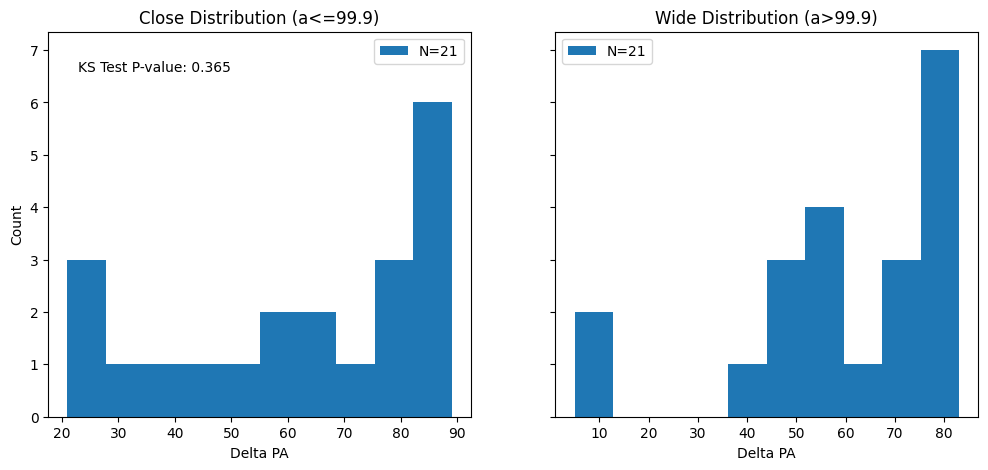

In [46]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
ax[0].hist(close_separation['delta_PA'], label=f'N={len(close_separation)}')
ax[1].hist(wide_separation['delta_PA'], label=f'N={len(wide_separation)}')

ax[0].set_title(f"Close Distribution (a<={median_separation})")
ax[0].set_ylabel("Count")
ax[0].set_xlabel("Delta PA")
ax[0].legend()

ax[1].set_title(f"Wide Distribution (a>{median_separation})")
ax[1].set_xlabel("Delta PA")
ax[1].legend()

fig.text(0.15, 0.80, f"KS Test P-value: {round(ks_test.pvalue, 3)}")

plt.show()

There appears to be marginal differences between the delta PA distributions of close and wide binaries. The distribution of wider binaries is skewed more towards being orthogonal. The KS Test is inconclusive with a p-value of 0.365.